In [28]:
# Step A: Imports and data loading
import pandas as pd
import numpy as np
import itertools
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, f1_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

import networkx as nx

RAW_FILE = r"C:\Users\ahafeez7\Downloads\covid_prediction_project\COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03.csv"
KB_FILE = r"C:\Users\ahafeez7\Downloads\covid_prediction_project\COVIDCARE_DEMI_knowledgebase_v3.csv"

df = pd.read_csv(RAW_FILE)
kb = pd.read_csv(KB_FILE)

df.columns = [c.strip() for c in df.columns]
kb.columns = [c.strip() for c in kb.columns]

TARGET = "PCR Test Positive"

print("Loaded:", df.shape, kb.shape)

Loaded: (822, 472) (70983, 13)


In [29]:
# Step B: Tier assignment and KB setup
def assign_tier(col):
    c = str(col).lower()
    if c == "pcr test positive": return 4
    if any(k in c for k in ["pink","blue","athome","testkit"]): return 3
    if any(k in c for k in ["vaccine","vacc"]): return 1
    if any(k in c for k in ["age","gender","race","ethnicity"]): return 0
    return 2

kb = kb[kb["concept_code"] != kb["target_concept_code"]].copy()

kb["concept_tier"] = kb["concept_code"].map(assign_tier).fillna(2)
kb["target_tier"] = kb["target_concept_code"].map(assign_tier).fillna(2)

In [30]:
# Step C: Temporal rules

def apply_temporal(row):
    n11, n10, n01 = row["n_code_target"], row["n_code_no_target"], row["n_target_no_code"]
    ct, tt = row["concept_tier"], row["target_tier"]

    if n11 == 0:
        row["code_before"] = n10
        row["target_before"] = n01
    elif ct < tt:
        row["code_before"] = n11
        row["target_before"] = 0
    elif ct > tt:
        row["code_before"] = 0
        row["target_before"] = n11
    else:
        row["code_before"] = n11
        row["target_before"] = n11
    return row

kb = kb.apply(apply_temporal, axis=1)

In [31]:
# Step D: Pairwise associations
kb["odds_ratio"] = ((kb["n_code_target"]+0.5)*(kb["n_no_code_no_target"]+0.5))/(
    (kb["n_code_no_target"]+0.5)*(kb["n_target_no_code"]+0.5)
)

num = kb["n_code_target"]*kb["n_no_code_no_target"] - kb["n_code_no_target"]*kb["n_target_no_code"]
den = np.sqrt(
    (kb["n_code_target"]+kb["n_code_no_target"])*
    (kb["n_target_no_code"]+kb["n_no_code_no_target"])*
    (kb["n_code_target"]+kb["n_target_no_code"])*
    (kb["n_code_no_target"]+kb["n_no_code_no_target"])
)

kb["phi"] = np.where(den==0, np.nan, num/den)

In [32]:
# Step E: Frequency of co-occurrence
pair_freq = kb[["concept_code","target_concept_code","n_code_target"]]
pair_freq = pair_freq.sort_values("n_code_target", ascending=False)

print(pair_freq.head())

                   concept_code       target_concept_code  n_code_target
27995   30160-Symptom_Inflamm-1     31386-covid_results-2            584
47322       31405-skipped_why-4     31386-covid_results-2            582
70396  bin_32136-vaccine_didyou   bin_30171-COVID_vaccine            577
69885   bin_30171-COVID_vaccine  bin_32136-vaccine_didyou            577
36690       31344-devices_own-3     31386-covid_results-2            576


In [55]:
# Step F: Data Prep
model_df = df.copy()

model_df[TARGET] = pd.to_numeric(model_df[TARGET], errors="coerce")
model_df = model_df.dropna(subset=[TARGET])
model_df[TARGET] = model_df[TARGET].astype(int)

X_full = pd.get_dummies(model_df.drop(columns=[TARGET]), drop_first=True)

# Remove leakage variables explicitly
leakage_keywords = ["pcr", "result", "date", "deid", "internal", "cohort"]

def is_leakage(col):
    c = col.lower()
    return any(k in c for k in leakage_keywords)

X_full = X_full[[c for c in X_full.columns if not is_leakage(c)]]

y = model_df[TARGET]

In [56]:
# Step G: Split and feature selection
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_full, y, test_size=0.25, stratify=y, random_state=42
)

mi = mutual_info_classif(X_train_base.fillna(0), y_train)

mi_df = pd.DataFrame({
    "feature": X_train_base.columns,
    "mi": mi
}).sort_values("mi", ascending=False)

selected_features = mi_df.head(40)["feature"].tolist()

X_train_base = X_train_base[selected_features]
X_test_base = X_test_base[selected_features]

In [57]:
# Step H: Interactions
symptom_vars = [c for c in selected_features if assign_tier(c) in [2,3]]

pair_base = symptom_vars[:15]
triple_base = symptom_vars[:6]

def create_interactions(X):
    Xn = X.copy()
    for a,b in itertools.combinations(pair_base,2):
        Xn[f"{a}__{b}"] = X[a]*X[b]
    for a,b,c in itertools.combinations(triple_base,3):
        Xn[f"{a}__{b}__{c}"] = X[a]*X[b]*X[c]
    return Xn

X_train = create_interactions(X_train_base)
X_test = create_interactions(X_test_base)

In [58]:
# Step I: Modeling and evaluation
prep = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("sc", StandardScaler(with_mean=False))
])

log_model = Pipeline([
    ("prep", prep),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

lasso_model = Pipeline([
    ("prep", prep),
    ("model", LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        cv=5,
        max_iter=5000,
        scoring="roc_auc"
    ))
])

def mcfadden_r2(y, p):
    p = np.clip(p,1e-8,1-1e-8)
    ll = -log_loss(y,p,normalize=False)
    null = -log_loss(y,np.repeat(np.mean(y),len(y)),normalize=False)
    return 1 - ll/null

results = []
fitted_models = {}

for name, model in {"Logistic":log_model,"LASSO":lasso_model}.items():
    model.fit(X_train,y_train)
    fitted_models[name] = model

    prob = model.predict_proba(X_test)[:,1]
    pred = (prob>0.5).astype(int)

    results.append({
        "Model":name,
        "AUC":roc_auc_score(y_test,prob),
        "F1":f1_score(y_test,pred),
        "McFadden_R2":mcfadden_r2(y_test,prob)
    })

results_df = pd.DataFrame(results).sort_values("AUC",ascending=False)
print(results_df)

      Model       AUC        F1  McFadden_R2
1     LASSO  0.946933  0.733333     0.357354
0  Logistic  0.919733  0.645161    -0.213933


In [61]:
# step J: Direct predictors
lasso_fitted = fitted_models["LASSO"].named_steps["model"]
coef = pd.Series(lasso_fitted.coef_[0], index=X_train.columns)

direct_predictors = coef[coef != 0].sort_values(key=abs, ascending=False)
print(direct_predictors.head(20))

32730-howreceive                                                          0.939586
29790-consent_applies                                                    -0.565991
30158-Symtpom_Neuro-7__30769-blue_nopink_confirm                          0.489624
32730-howreceive__29792-consent_covid+                                   -0.482387
32137-vaccine_avail                                                       0.478685
30769-blue_nopink_confirm__32016-time_picker                             -0.420974
30766-pinkblue_confirm                                                    0.368651
30153-Symptoms-2                                                          0.286587
30132-covid_tested30__30766-pinkblue_confirm                              0.275852
30138-COVID_Why-1__30766-pinkblue_confirm                                 0.242864
30766-pinkblue_confirm__30153-Symptoms-1                                 -0.239839
30158-Symtpom_Neuro-7__29790-consent_applies                              0.228809
3015

In [62]:
# Step K: Parent regression - Markov Blanket
from sklearn.impute import SimpleImputer

def fit_parent_model(response_var):
    response_tier = assign_tier(response_var)
    parents = [c for c in X_train.columns if assign_tier(c) < response_tier]

    if len(parents) == 0:
        return None, None

    Xp = X_train[parents]
    yp = y_train

    # Impute missing values
    imputer = SimpleImputer(strategy="most_frequent")
    Xp = pd.DataFrame(imputer.fit_transform(Xp), columns=Xp.columns, index=Xp.index)

    # Check valid target
    if yp.nunique() < 2:
        return None, None

    model = LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        cv=5,
        max_iter=5000
    )

    model.fit(Xp, yp)
    prob = model.predict_proba(Xp)[:,1]

    r2 = mcfadden_r2(yp, prob)

    coef_df = pd.DataFrame({
        "parent": parents,
        "coef": model.coef_[0]
    })

    coef_df = coef_df[coef_df["coef"] != 0]
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)

    return coef_df, r2

In [63]:
# Step L: Network, CPT, prediction
G = nx.DiGraph()

for response_var, result in markov_results.items():
    for _, row in result["coef"].iterrows():
        G.add_edge(row["parent"], response_var)

    G.add_edge(response_var, TARGET)

def create_cpt(parents):
    if len(parents) == 0:
        return None

    combos = list(itertools.product([0,1], repeat=len(parents)))
    cpt = pd.DataFrame(combos, columns=parents)

    model = LogisticRegression(max_iter=5000)
    model.fit(X_train[parents], y_train)

    cpt["prob"] = model.predict_proba(cpt)[:,1]
    return cpt

best_model = fitted_models["Logistic"]

def predict_case(input_dict):
    row = pd.DataFrame(0, index=[0], columns=X_train.columns)
    for k,v in input_dict.items():
        if k in row.columns:
            row[k] = v
    return best_model.predict_proba(row)[0,1]

Graph empty → using fallback (direct predictors → PCR)


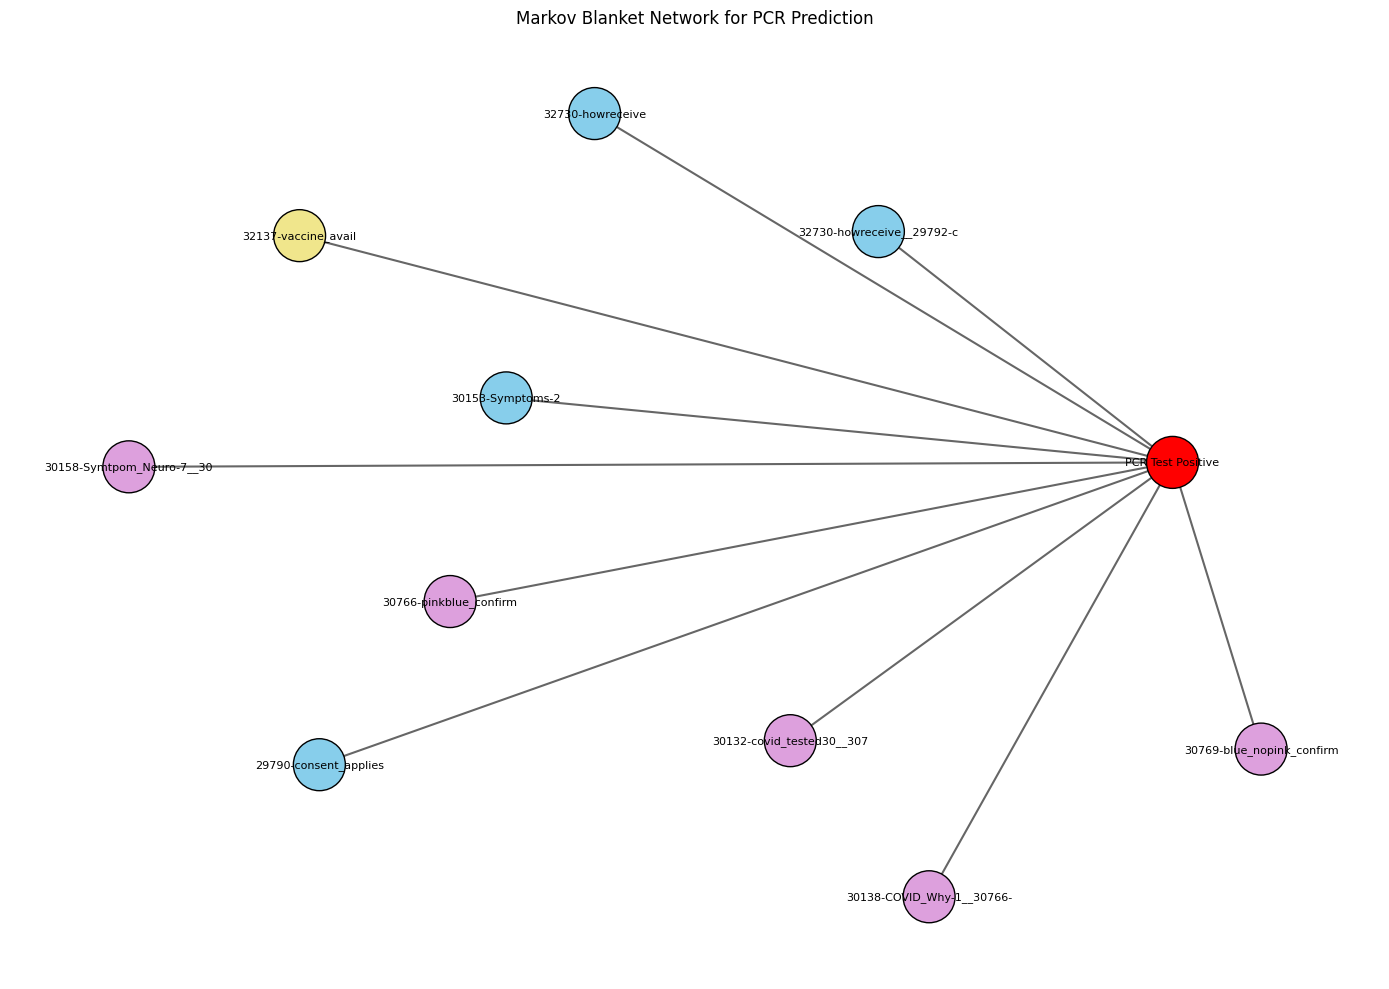

Nodes: 11 Edges: 10


In [64]:
# Step L-1: draw the network
import matplotlib.pyplot as plt

# Check if graph is empty
if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
    print("Graph empty → using fallback (direct predictors → PCR)")
    G = nx.DiGraph()
    for var in direct_predictors.index[:10]:
        G.add_edge(var, TARGET)

# Layout
pos = nx.spring_layout(G, k=0.6, seed=42)

# Color nodes by tier
node_colors = []
for node in G.nodes():
    t = assign_tier(node)
    if node == TARGET:
        node_colors.append("red")
    elif t == 0:
        node_colors.append("lightgreen")
    elif t == 1:
        node_colors.append("khaki")
    elif t == 2:
        node_colors.append("skyblue")
    elif t == 3:
        node_colors.append("plum")
    else:
        node_colors.append("gray")

# Shorten labels for readability
labels = {n: str(n)[:25] for n in G.nodes()}

# Draw
plt.figure(figsize=(14,10))

nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    alpha=0.6,
    width=1.5,
    arrowstyle='-|>',
    arrowsize=12
)

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=1400,
    edgecolors="black"
)

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=8
)

plt.title("Markov Blanket Network for PCR Prediction")
plt.axis("off")
plt.tight_layout()
plt.show()

# Debug info
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

In [65]:
# step M: Probability calibration
from sklearn.calibration import CalibratedClassifierCV
calibrated_model = CalibratedClassifierCV(best_model, method="isotonic", cv=3)
calibrated_model.fit(X_train, y_train)

prob_cal = calibrated_model.predict_proba(X_test)[:,1]

print("Calibrated AUC:", roc_auc_score(y_test, prob_cal))

Calibrated AUC: 0.9288


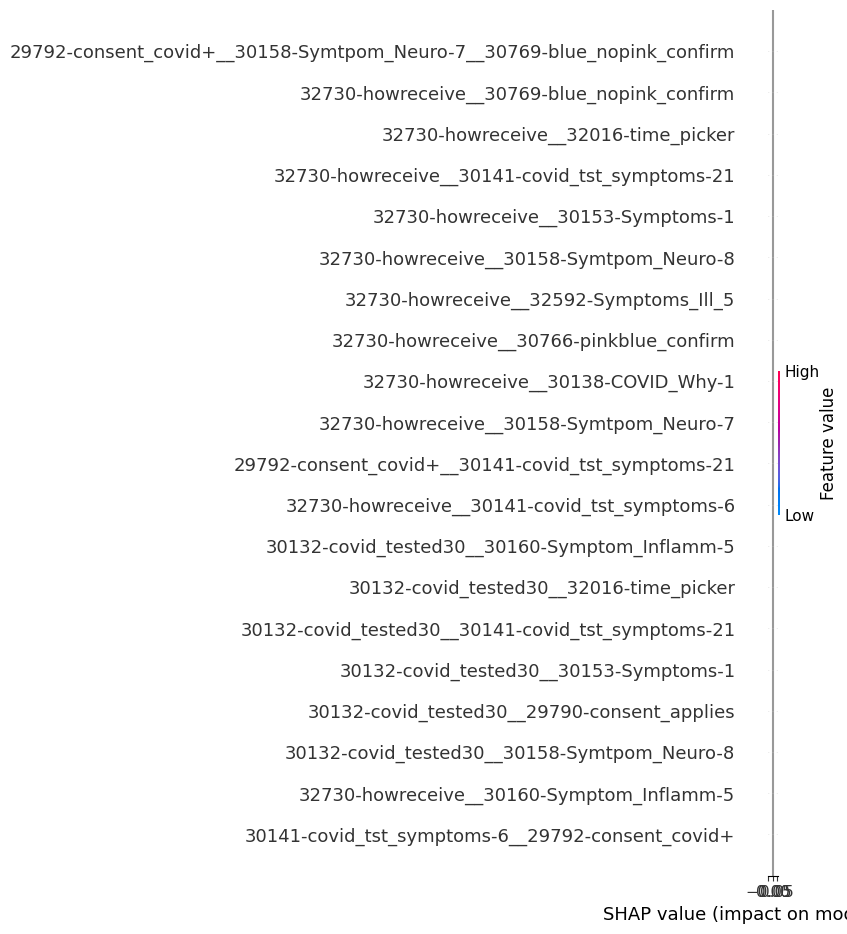

In [68]:
# step N:import shap
import shap

# Ensure numeric data
X_train_num = X_train.astype(float)
X_test_num = X_test.astype(float)

model_core = best_model.named_steps["model"]

explainer = shap.Explainer(model_core, X_train_num)

X_sample = X_test_num.sample(min(200, len(X_test_num)), random_state=42)

shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample)